# Gold price prediction with python

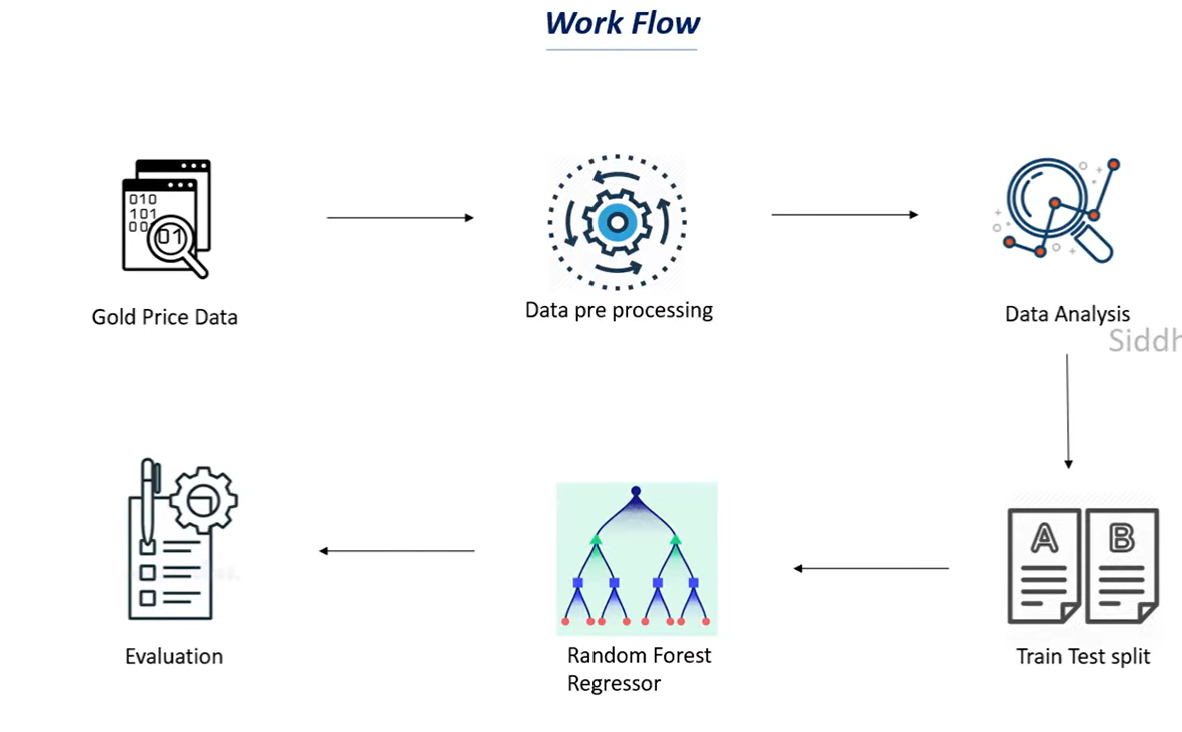


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

import kagglehub

path = kagglehub.dataset_download("altruistdelhite04/gold-price-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gold-price-data' dataset.
Path to dataset files: /kaggle/input/gold-price-data


In [2]:
import os

# List contents of the downloaded directory to find the correct CSV file name
print(os.listdir(path))

# Assuming the correct file name is 'gld_price_data.csv' based on typical Kaggle datasets
# If the above print statement shows a different name, please update 'gld_price_data.csv' accordingly
csv_file_path = os.path.join(path, 'gld_price_data.csv')
df = pd.read_csv(csv_file_path)
display(df.head())

['gld_price_data.csv']


,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [3]:
# data collecting & processing
df.head()

# spx -> capitalization index
# gld -> gold prices
# uso -> united states oil price

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
df.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [5]:
df.shape

(2290, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
df.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [8]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [9]:
# find correlation

'''
1. positive correlation
one variable will increase other will increase (directly proportional)

2. negative correlation
one variable will decrease other will increase (indirectly proportional)
'''

# Exclude non-numeric columns like 'Date' from correlation calculation
correlation = df.drop('Date', axis=1).corr()

<Axes: >

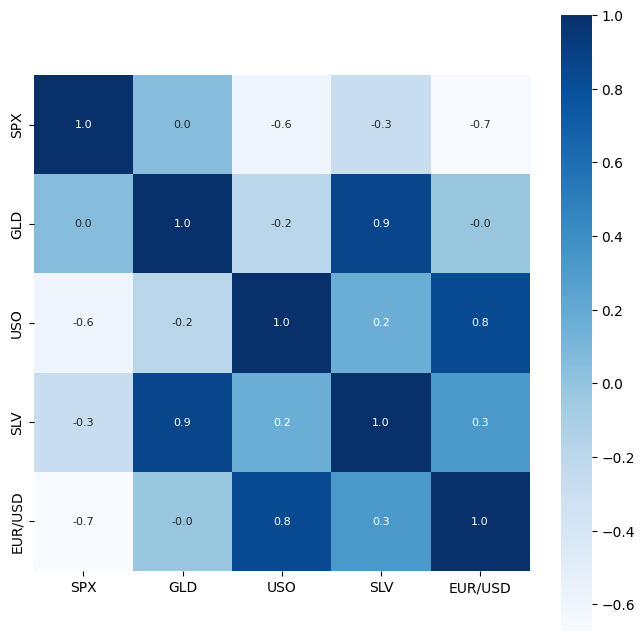

In [10]:
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar=True, square=True,fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [11]:
# correlation values
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipython-input-2580196265.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['GLD'], color='green')


<Axes: xlabel='GLD', ylabel='Density'>

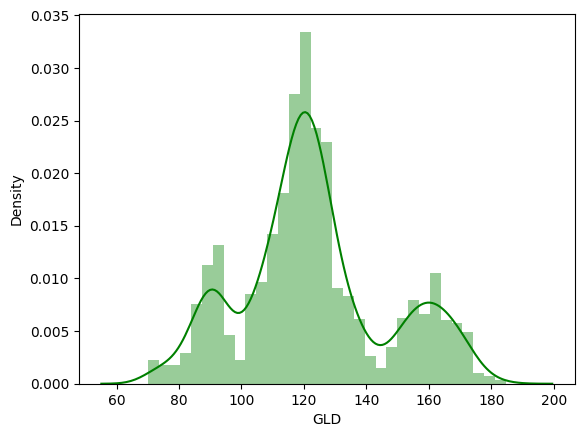

In [12]:
# check the distribution of GLD
sns.distplot(df['GLD'], color='green')

In [13]:
# y -> date, gld
# x -> date, rest other

# splitting the features and target

X = df.drop(['Date', 'GLD'], axis=1)
Y = df['GLD']

In [14]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [15]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=2)

In [17]:
# model training - random forest regressor model works
# random forest algorithm

regressor = RandomForestRegressor(n_estimators=100)

In [18]:
# training the model
regressor.fit(X_train, Y_train)

RandomForestRegressor()

In [19]:
# model evaluation

# prediction on test data
test_data_prediction = regressor.predict(X_test)

In [20]:
print(test_data_prediction)

[168.51489933  82.07259973 116.07410027 127.57320011 120.85280113
 154.59289681 150.33509803 126.06930082 117.37849886 125.9704007
 116.56190076 171.81190078 142.08849815 167.92269863 115.1728999
 117.6115006  139.6614032  170.15520053 158.73330342 158.05289922
 155.14750041 124.61790007 175.83389998 156.96520355 125.25760047
  93.74989966  77.35850065 120.72890014 119.13589926 167.44029895
  88.11120057 125.12909959  90.89560043 117.57740049 121.08339938
 136.51120061 115.63950158 115.07370073 147.88979977 107.3921011
 104.47330271  87.26839807 126.53450072 117.94369976 153.66309863
 119.70009997 108.32429944 108.22609852  93.08820015 127.08799787
  75.29480044 113.70569884 121.31640002 111.31649895 118.75999885
 120.68619939 159.81370095 168.30160139 146.99199643  86.02849876
  94.45020029  86.84109916  90.42399986 119.03600057 126.42890042
 127.47340013 169.50369949 122.21019919 117.33049909  98.78350012
 168.59080069 142.80959816 131.61640201 121.17960221 120.41519961
 119.62990052

In [21]:
# r squared error

error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.9886373518704958


In [22]:
# compare the actual values and predicted values in a plot

Y_test = list(Y_test)

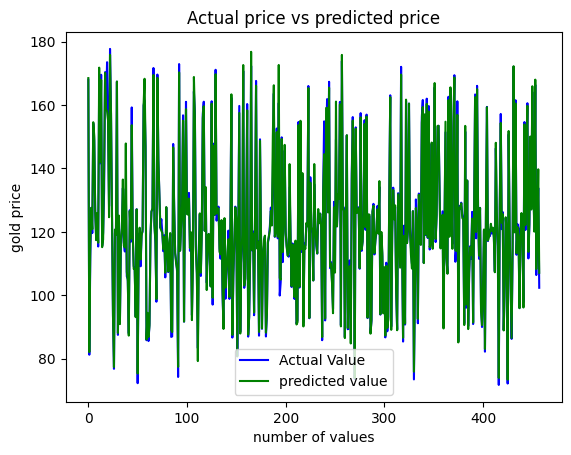

In [23]:
plt.plot(Y_test, color='blue', label='Actual Value')
plt.plot(test_data_prediction, color='green', label='predicted value')
plt.title("Actual price vs predicted price")
plt.xlabel("number of values")
plt.ylabel("gold price")
plt.legend()
plt.show()